In [1]:
import sklearn
print(sklearn.__version__)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Other plots (example)

from src.exp import (
    ExperimentConfig, ExperimentFacade,
    DataReadConfig, PlotManager
    
)

1.8.0


In [2]:
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("Intel sklearn patch enabled")
except ImportError:
    print("sklearnex not installed; using standard sklearn")


sklearnex not installed; using standard sklearn


In [3]:
data_cfg = DataReadConfig(
    root_dir="Dataset/data",
    recursive=True,
    exclude_filenames=["cclass.csv", "unclean focus.csv","unclean cclass.csv","focus.csv"],  # the excluded files
    add_source_column=False,        # enable this to make additional column filled with the original taken filenames
)

In [4]:
cfg = ExperimentConfig(
    outer_folds=5, 
    inner_folds=5, 
    n_trials=40, 
    seed=42, 
    log_target=True
)

In [5]:
models = ["LinearRegression", "DecisionTree"]#["LinearRegression", "DecisionTree", "RandomForest", "SVR", "XGBoost", "NeuralNetwork"]

In [6]:
exp = ExperimentFacade.from_folder(
    data_cfg=data_cfg,
    target="price",
    cfg=cfg,
    model_names=models,
    hparam_json="config/hyperparams.json"
)

# model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize

[schema]
  numerical cols: ['year', 'mileage', 'tax', 'mpg', 'engineSize']
  categorical cols: ['model', 'transmission', 'fuelType']
  target col: ['price']
  mapping: {'model': 'model', 'year': 'year', 'price': 'price', 'transmission': 'transmission', 'mileage': 'mileage', 'fuelType': 'fuelType', 'tax': 'tax', 'mpg': 'mpg', 'engineSize': 'engineSize'}


In [7]:
results = exp.run()

[I 2026-01-26 11:01:08,449] A new study created in memory with name: LinearRegression_OuterFold_1_residual_cfg_base
[I 2026-01-26 11:01:09,350] Trial 0 finished with value: -2.974530247368404 and parameters: {}. Best is trial 0 with value: -2.974530247368404.
[I 2026-01-26 11:01:09,390] Trial 1 finished with value: -2.974530247368404 and parameters: {}. Best is trial 0 with value: -2.974530247368404.
[I 2026-01-26 11:01:09,428] Trial 2 finished with value: -2.974530247368404 and parameters: {}. Best is trial 0 with value: -2.974530247368404.
[I 2026-01-26 11:01:09,467] Trial 3 finished with value: -2.974530247368404 and parameters: {}. Best is trial 0 with value: -2.974530247368404.
[I 2026-01-26 11:01:09,505] Trial 4 finished with value: -2.974530247368404 and parameters: {}. Best is trial 0 with value: -2.974530247368404.
[I 2026-01-26 11:01:09,544] Trial 5 finished with value: -2.974530247368404 and parameters: {}. Best is trial 0 with value: -2.974530247368404.
[I 2026-01-26 11:01:

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/hyperparameters/best_hyperparameters.json
[final fit] LinearRegression
[saved] LinearRegression
[final fit] DecisionTree
[saved] DecisionTree


In [8]:
display(exp.summary())


,model,R2_mean,R2_std,MAE_mean,MAE_std,MedAE_mean,MedAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std
0,DecisionTree,0.945727,0.005862,1296.659373,21.257888,802.298581,10.720990,5.282343e+06,5.736491e+05,2295.564252,126.132377
1,LinearRegression,-2.606856,7.771180,2110.810040,122.029471,1332.976244,7.017524,3.529705e+08,7.606829e+08,11138.970659,16915.000996


In [9]:
sig = exp.significance(
    metric="R2",
    baseline="LinearRegression",
    models=["DecisionTree"]
)

In [10]:
display(sig)

,metric,baseline,model,paired_t_p,wilcoxon_p,n_outer_folds
0,R2,LinearRegression,DecisionTree,0.364283,0.0625,5


In [11]:
shap_analyzer = exp.shap(models=models)

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_linearregression.png


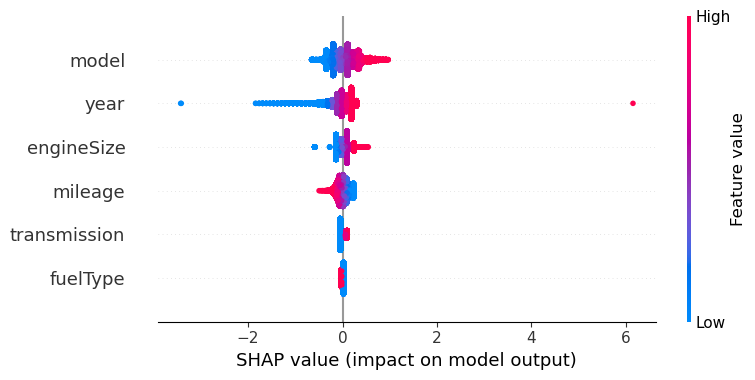

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_decisiontree.png


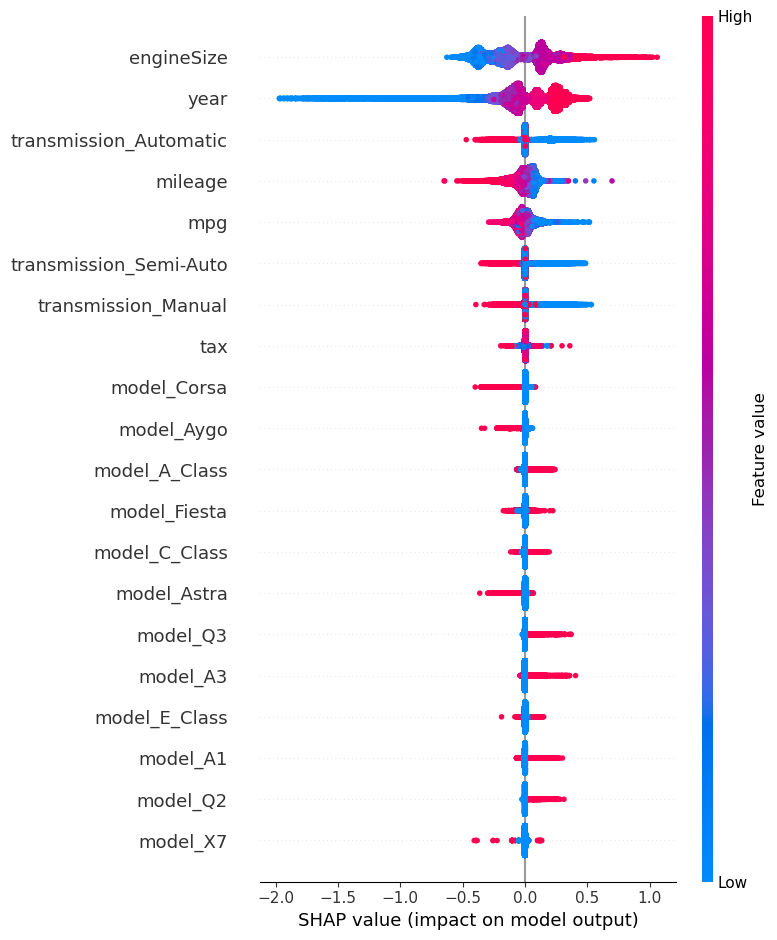

In [12]:
for m in shap_analyzer.available_models():
    shap_analyzer.beeswarm(m)

In [13]:
def plot_model_comparison(df_summary, plot_manager=None):

    df_summary.set_index("model")["R2_mean"].plot(kind="bar")
    plt.ylabel("R2")

    if plot_manager is not None:
        plot_manager.save("model_comparison_r2")
    plt.show()


In [14]:
exp.summary()

,model,R2_mean,R2_std,MAE_mean,MAE_std,MedAE_mean,MedAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std
0,DecisionTree,0.945727,0.005862,1296.659373,21.257888,802.298581,10.720990,5.282343e+06,5.736491e+05,2295.564252,126.132377
1,LinearRegression,-2.606856,7.771180,2110.810040,122.029471,1332.976244,7.017524,3.529705e+08,7.606829e+08,11138.970659,16915.000996


[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/model_comparison_r2.png


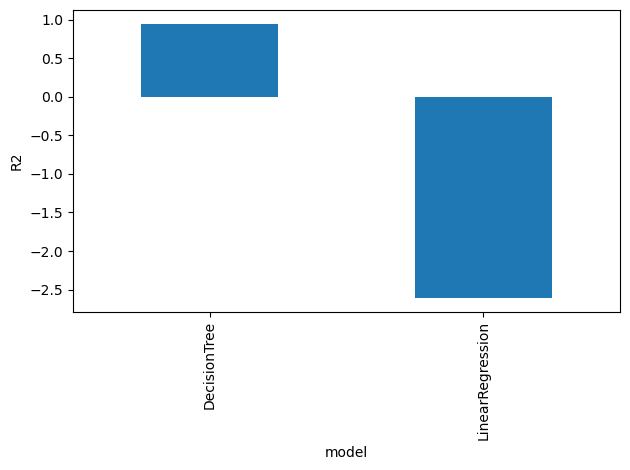

In [15]:

pm = PlotManager("outputs/figures/metrics")
plot_model_comparison(exp.summary(), plot_manager=pm)

In [16]:
display(exp.significance_matrix(metric="R2"))

,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
0,R2,DecisionTree,LinearRegression,0.364283,0.0625,5


In [17]:
exp.save_best_params()

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/best_params/best_params.json
